In [ ]:
from langchain_openai import ChatOpenAI
llm=ChatOpenAI(model="gpt-5-nano")
llm.invoke("hi").content

'Hi there! How can I help today? If you’re not sure, tell me what you’re working on or curious about—math, writing, coding, planning, learning a new topic, or anything else. I can:\n- explain concepts or solve problems\n- draft or edit text\n- brainstorm ideas\n- summarize or translate\n- help with planning or study strategies\n- debug code\n\nWhat would you like to do?'

In [5]:
from typing import TypedDict, List
class model_schema(TypedDict):
    message:List

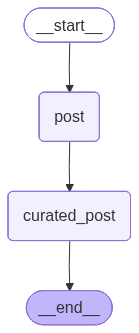

In [18]:
from langchain_core.messages import AIMessage,HumanMessage
from langgraph.graph import StateGraph,START,END

def post(dict1:model_schema)-> model_schema:
    message =dict1['message']
    response=llm.invoke(f"act as a lecturer and give me a beatiful lesson about {message}").content
    response_ai=AIMessage(content=response)
    dict1['message']+=[response_ai]
    return dict1

def curated_post(dict1:model_schema)->model_schema:
    message=dict1['message']
    response=llm.invoke(f"using the '{message}' please create multiple choice 5 questions and give me answers at the end").content
    response_ai=AIMessage(content=response)
    dict1['message']+=[response_ai]
    return dict1


graph=StateGraph(model_schema)
graph.add_node("post",post)
graph.add_node("curated_post",curated_post)
graph.add_edge(START, "post")
graph.add_edge("post","curated_post")
graph.add_edge("curated_post",END)

graph.compile()




In [20]:

# input1={"message":[HumanMessage(content="give me everything about python in 200 words .")]}
# type(input1)
# print(curated_post(input1))
# first_graph=graph.compile()
graph.compile().invoke({"message":[HumanMessage(content="give me everything about python in 200 words .")]})



{'message': [HumanMessage(content='give me everything about python in 200 words .', additional_kwargs={}, response_metadata={}),
  AIMessage(content='Good evening, class. Today we embark on a concise voyage through Python, a language that blends clarity, power, and playfulness. Created by Guido van Rossum and released in 1991, Python emphasizes readability and explicit intent, inviting beginners and experts to collaborate fruitfully. At its heart lies a simple syntax: indentation marks blocks, dynamic typing streams values through flexible containers, and a rich standard library offers tools from file handling to networking. Python supports multiple paradigms: procedural, object oriented, and functional styles coexist, allowing you to choose the approach that fits the problem. Beginners appreciate its simplicity; seasoned developers savor its expressiveness and feedback from an interactive shell or notebook.\n\nCrucial concepts include objects, modules, and packages that encourage modu